📈 Feature importances saved to data/processed/soil_feature_importances.csv


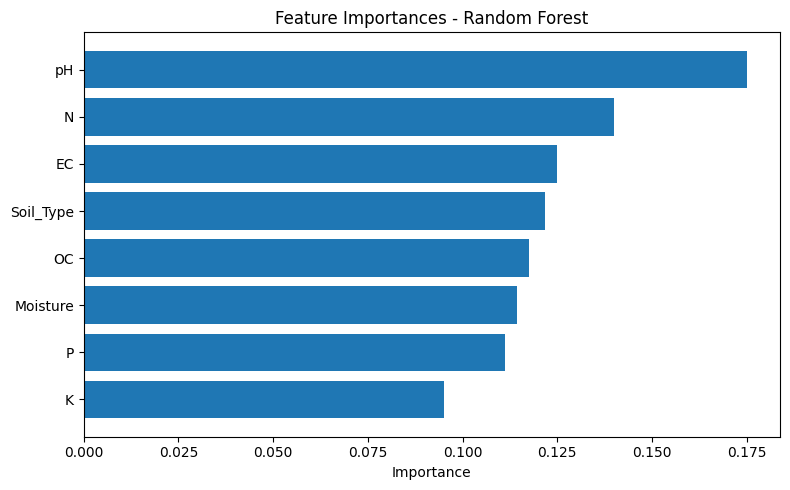

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importances = rf.feature_importances_
features = X.columns

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Save to CSV
importance_df.to_csv('../data/processed/soil_feature_importances.csv', index=False)
print("📈 Feature importances saved to data/processed/soil_feature_importances.csv")

# Plot feature importances
plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


In [17]:
# Save model accuracy to a text file
with open('../data/processed/model_accuracy_report.txt', 'w') as f:
    f.write(f"Random Forest Accuracy: {accuracy:.2f}\n")

print("📝 Accuracy saved to data/processed/model_accuracy_report.txt")


📝 Accuracy saved to data/processed/model_accuracy_report.txt


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Random Forest model trained successfully!")
print(f"🎯 Accuracy: {accuracy:.2f}\n")
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))



✅ Random Forest model trained successfully!
🎯 Accuracy: 0.20

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         1
           4       0.50      0.67      0.57         3
           5       0.00      0.00      0.00         1

    accuracy                           0.20        10
   macro avg       0.08      0.11      0.10        10
weighted avg       0.15      0.20      0.17        10



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

In [15]:
# Encode categorical columns properly
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()

# Encode relevant categorical columns
df_encoded['Soil_Type'] = le.fit_transform(df_encoded['Soil_Type'])
df_encoded['Crop_Suitability'] = le.fit_transform(df_encoded['Crop_Suitability'])

# Drop non-numeric identifiers that don't affect soil properties
df_encoded = df_encoded.drop(columns=['State', 'District', 'Farmer_ID'])

# Separate features and target
X = df_encoded.drop(columns=['Crop_Suitability'])
y = df_encoded['Crop_Suitability']

print("✅ Encoding complete!")
print("Feature columns:", X.columns.tolist())
print("Target distribution:")
print(y.value_counts())



✅ Encoding complete!
Feature columns: ['Soil_Type', 'pH', 'EC', 'OC', 'N', 'P', 'K', 'Moisture']
Target distribution:
Crop_Suitability
4    13
3     9
1     8
5     7
2     7
0     6
Name: count, dtype: int64


In [12]:
# Load the reduced dataset from Member 2
df = pd.read_csv('../data/processed/soil_reduced_features.csv')
print("✅ Reduced dataset loaded successfully!")
print(df.head())



✅ Reduced dataset loaded successfully!
         State    District Farmer_ID Soil_Type   pH    EC    OC    N   P    K  \
0  West Bengal  Darjeeling     F1000     Silty  5.9  0.75  0.53  236  37  149   
1  Maharashtra      Nagpur     F1001     Sandy  8.7  0.67  1.16  160  24  171   
2       Punjab    Ludhiana     F1002     Silty  7.1  1.06  0.88  173  15  114   
3        Bihar       Patna     F1003     Sandy  4.7  0.16  1.30  319  21  100   
4       Punjab    Amritsar     F1004     Loamy  4.8  0.99  0.81  395  18   93   

   Moisture Crop_Suitability  
0        34            Wheat  
1        37             Rice  
2        35            Wheat  
3        37           Pulses  
4        38             Rice  


In [9]:
# O3c_feature_importance.ipynb — Member 3

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

